# ViT против pretrained CNN: Intel Image Classification

Сравниваем компактный ViT (`WinKawaks/vit-small-patch16-224`, ~22 млн параметров) и ResNet-50 (`microsoft/resnet-50`, ~25 млн параметров) на одном и том же split из первого ноутбука.

Четыре эксперимента с одинаковым бюджетом (3 эпохи, batch 32, AdamW, cosine-расписание):

| Имя | Модель | Что обучается |
|---|---|---|
| `vit_frozen` | ViT-S/16 | только классификационная голова |
| `vit_partial` | ViT-S/16 | последние 4 блока энкодера, финальный LayerNorm и голова |
| `resnet_frozen` | ResNet-50 | только классификационная голова |
| `resnet_partial` | ResNet-50 | последняя стадия (`layer4`) и голова |

In [21]:
import os
import gc, json, time, random, hashlib
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms as T
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoImageProcessor, AutoModelForImageClassification, Trainer, TrainingArguments, set_seed

SEED = 42
EPOCHS, BATCH = 3, 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
WORK = Path('/kaggle/working')
RUNS, MODELS = WORK / 'runs', WORK / 'models'
CKPT = {'vit': 'WinKawaks/vit-small-patch16-224', 'resnet': 'microsoft/resnet-50'}
set_seed(SEED)
print(DEVICE, torch.cuda.get_device_name(0) if DEVICE == 'cuda' else '')

cuda Tesla T4


## 1. Тот же split, что и в дз 1

Код индексации, очистки (повреждённые файлы, пересечения с test/pred, конфликты меток, копии) и стратифицированного split скопирован из первого ноутбука без изменений.

In [22]:
ROOT = Path('/kaggle/input/datasets/puneet6060/intel-image-classification')
PARTS = ('seg_train', 'seg_test', 'seg_pred')

def inspect_file(p):
    part = next((s for s in PARTS if s in p.parts), None)
    row = dict(path=str(p), part=part, label=p.parent.name if part in PARTS[:2] else None,
               md5=hashlib.md5(p.read_bytes()).hexdigest(), corrupt=False)
    try:
        with Image.open(p) as im:
            im.load()
    except Exception:
        row['corrupt'] = True
    return row

files = sorted(p for p in ROOT.rglob('*') if p.is_file())
with ThreadPoolExecutor(8) as pool:
    df = pd.DataFrame(list(tqdm(pool.map(inspect_file, files), total=len(files))))
df['dup_labels'] = df.groupby('md5').label.transform('nunique')

classes = sorted(df[df.part.isin(PARTS[:2])].label.unique())
class2idx = {c: i for i, c in enumerate(classes)}

test_hashes = set(df[df.part != 'seg_train'].md5)
tr = df[(df.part == 'seg_train') & ~df.corrupt].copy()
tr = tr[~tr.md5.isin(test_hashes)]
tr = tr[tr.dup_labels <= 1]
tr = tr.drop_duplicates('md5')
tr['y'] = tr.label.map(class2idx)
cols = ['path', 'label', 'y', 'md5']

train_df, val_df = train_test_split(tr[cols], test_size=0.2, stratify=tr.y, random_state=SEED)
train_df, val_df = train_df.sort_values('path').reset_index(drop=True), val_df.sort_values('path').reset_index(drop=True)
test_df = df[(df.part == 'seg_test') & ~df.corrupt].assign(y=lambda d: d.label.map(class2idx))[cols].reset_index(drop=True)

for a, b in ((train_df, val_df), (train_df, test_df), (val_df, test_df)):
    assert not set(a.md5) & set(b.md5)

labels = classes
id2label = dict(enumerate(labels)); label2id = {v: k for k, v in id2label.items()}
print({k: len(v) for k, v in (('train', train_df), ('val', val_df), ('test', test_df))}, labels)

  0%|          | 0/24335 [00:00<?, ?it/s]

{'train': 11188, 'val': 2798, 'test': 3000} ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 2. Данные и обучение

Image processor у каждой модели свой, он берётся из репозитория модели через `AutoImageProcessor`: он знает размер входа, интерполяцию, нужен ли центральный кроп и какие mean/std использовать (у ViT-S это 0.5/0.5, у ResNet-50 — статистики ImageNet). Аугментации до processor общие для обеих моделей: случайный кроп (масштаб 0.6–1.0), горизонтальное отражение, умеренный `ColorJitter` — те же, что в первом ноутбуке. Validation и test идут без аугментаций.

Исходные изображения 150×150 увеличиваются processor до 224×224. Новой информации при этом нет, но модели обучались именно на входах 224×224.

In [23]:
processors = {k: AutoImageProcessor.from_pretrained(v) for k, v in CKPT.items()}
for k, p in processors.items():
    print(k, type(p).__name__, '| size', p.size, '| mean', p.image_mean, '| std', p.image_std, '| crop_pct', getattr(p, 'crop_pct', None))

aug = T.Compose([
    T.RandomResizedCrop(150, scale=(0.6, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(0.5),
    T.ColorJitter(0.2, 0.2, 0.2, 0.02),
])

class HFDataset(Dataset):
    def __init__(self, frame, processor, train):
        self.paths, self.y, self.processor, self.train = frame.path.tolist(), frame.y.tolist(), processor, train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        with Image.open(self.paths[i]) as im:
            img = im.convert('RGB')
        if self.train:
            img = aug(img)
        return {'pixel_values': self.processor(img, return_tensors='pt')['pixel_values'][0], 'labels': self.y[i]}

def compute_metrics(ev):
    pred = ev.predictions.argmax(-1)
    return {'accuracy': accuracy_score(ev.label_ids, pred), 'macro_f1': f1_score(ev.label_ids, pred, average='macro')}

def set_trainable(model, patterns):
    for n, p in model.named_parameters():
        p.requires_grad = any(k in n for k in patterns)
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d) and not any(p.requires_grad for p in m.parameters()):
            m.train = lambda mode=True, m=m: m  # замороженные BN остаются в eval: статистики не дрейфуют
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

PATTERNS = {
    'vit_frozen': ['classifier'],
    'vit_partial': [f'vit.layers.{i}.' for i in (8, 9, 10, 11)] + ['vit.layernorm', 'classifier'],
    'resnet_frozen': ['classifier'],
    'resnet_partial': ['stages.3', 'classifier'],
}
LR = {'vit_frozen': 1e-3, 'vit_partial': 1e-4, 'resnet_frozen': 1e-3, 'resnet_partial': 1e-4}

STATS = WORK / 'train_stats.json'
stats = json.loads(STATS.read_text()) if STATS.exists() else {}

def run(name):
    family = name.split('_')[0]
    set_seed(SEED)
    proc = processors[family]
    model = AutoModelForImageClassification.from_pretrained(
        CKPT[family], num_labels=len(labels), id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)
    n_train = set_trainable(model, PATTERNS[name])
    assert 'partial' not in name or n_train > 1e6, f'{name}: паттерны не совпали с именами параметров, обучаемых {n_train}'
    args = TrainingArguments(
        output_dir=str(RUNS / name), num_train_epochs=EPOCHS, per_device_train_batch_size=BATCH, per_device_eval_batch_size=64,
        learning_rate=LR[name], weight_decay=0.01, lr_scheduler_type='cosine', warmup_steps=0.1,
        eval_strategy='epoch', save_strategy='no',fp16=DEVICE == 'cuda', dataloader_num_workers=2,
        remove_unused_columns=False, seed=SEED, data_seed=SEED, report_to='none', logging_steps=100)
    trainer = Trainer(model=model, args=args, train_dataset=HFDataset(train_df, proc, True),
                      eval_dataset=HFDataset(val_df, proc, False), compute_metrics=compute_metrics)
    if DEVICE == 'cuda':
        torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    trainer.train()
    stats[name] = dict(trainable_params=n_train, train_min=(time.time() - t0) / 60,
                       train_peak_mem_mb=torch.cuda.max_memory_allocated() / 2 ** 20 if DEVICE == 'cuda' else float('nan'),
                        val_macro_f1=trainer.evaluate()['eval_macro_f1'])
    STATS.write_text(json.dumps(stats, indent=1))
    d = MODELS / name
    trainer.model.save_pretrained(d); proc.save_pretrained(d)
    del trainer, model, args
    gc.collect(); torch.cuda.empty_cache()
    return stats[name]

vit ViTImageProcessor | size SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None) | mean (0.5, 0.5, 0.5) | std (0.5, 0.5, 0.5) | crop_pct None
resnet ConvNextImageProcessor | size SizeDict(height=None, width=None, longest_edge=None, shortest_edge=224, max_height=None, max_width=None) | mean (0.485, 0.456, 0.406) | std (0.229, 0.224, 0.225) | crop_pct 0.875


### 2.1 Обучение

In [25]:
stats = json.loads(STATS.read_text())
stats.pop('vit_partial', None)
for v in stats.values():
    v['val_macro_f1'] = v.pop('val_macro_f1')
STATS.write_text(json.dumps(stats, indent=1))
print({k: round(v['val_macro_f1'], 4) for k, v in stats.items()})


{'vit_frozen': 0.9416, 'resnet_frozen': 0.91, 'resnet_partial': 0.9277}


In [26]:
run('vit_frozen')

[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 384]) vs model:torch.Size([6, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([6])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.599962,0.182958,0.938528,0.939709
2,0.163495,0.174286,0.937098,0.938116
3,0.156657,0.170722,0.940672,0.941578


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.156657,0.170722,3,0.940672,0.941578


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'trainable_params': 2310,
 'train_min': 2.8945286830266315,
 'train_peak_mem_mb': 788.49072265625,
 'val_macro_f1': 0.9415776252867496}

In [27]:
run('vit_partial')

[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 384]) vs model:torch.Size([6, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([6])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.479224,0.143614,0.950322,0.951122
2,0.118102,0.132164,0.955683,0.956284
3,0.085626,0.135378,0.957470,0.958053


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.085626,0.135378,3,0.957470,0.958053


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'trainable_params': 7100934,
 'train_min': 3.0074164589246113,
 'train_peak_mem_mb': 1212.91748046875,
 'val_macro_f1': 0.9580527658671741}

In [28]:
run('resnet_frozen')

In [29]:
run('resnet_partial')

## 3. Функция inference с полной предобработкой

`Predictor` принимает путь, `PIL.Image` или RGB-массив `numpy` (или список таких объектов), сам приводит к RGB, прогоняет через image processor модели и возвращает top-k классов с вероятностями. Эта же функция используется для оценки на test и в тестах устойчивости, поэтому предобработка при оценке и при применении одна и та же.

In [30]:
class Predictor:
    def __init__(self, model, processor, labels, device=DEVICE):
        self.model, self.processor, self.labels, self.device = model.to(device).eval(), processor, labels, device

    @staticmethod
    def load(x):
        if isinstance(x, (str, Path)):
            x = Image.open(x)
        elif isinstance(x, np.ndarray):
            x = Image.fromarray(x)
        return x.convert('RGB')

    @torch.inference_mode()
    def logits(self, images, bs=64):
        out = []
        for i in range(0, len(images), bs):
            pv = self.processor([self.load(x) for x in images[i:i + bs]], return_tensors='pt')['pixel_values'].to(self.device)
            out.append(self.model(pixel_values=pv).logits.float().cpu())
        return torch.cat(out)

    def predict(self, images, topk=3):
        single = not isinstance(images, (list, tuple))
        probs = self.logits([images] if single else images).softmax(-1)
        top = probs.topk(topk)
        res = [[(self.labels[j], round(p, 4)) for j, p in zip(ix.tolist(), pr.tolist())] for ix, pr in zip(top.indices, top.values)]
        return res[0] if single else res

def load_predictor(name):
    d = MODELS / name
    return Predictor(AutoModelForImageClassification.from_pretrained(d), AutoImageProcessor.from_pretrained(d), labels)

NAMES = list(PATTERNS)
P = {n: load_predictor(n) for n in NAMES}

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

## 4. Качество на test

In [31]:
yt = test_df.y.values
LOGITS = {n: P[n].logits(test_df.path.tolist()) for n in NAMES}
PRED = {n: LOGITS[n].argmax(1).numpy() for n in NAMES}

quality = pd.DataFrame({
    n: {'accuracy': accuracy_score(yt, PRED[n]), 'macro_f1': f1_score(yt, PRED[n], average='macro'),
        'val_macro_f1': stats[n]['val_macro_f1']} for n in NAMES}).T
quality.round(4)

,accuracy,macro_f1,val_macro_f1
vit_frozen,0.9407,0.9422,0.9416
vit_partial,0.9497,0.9507,0.9581
resnet_frozen,0.9003,0.9028,0.9100
resnet_partial,0.9203,0.9223,0.9277


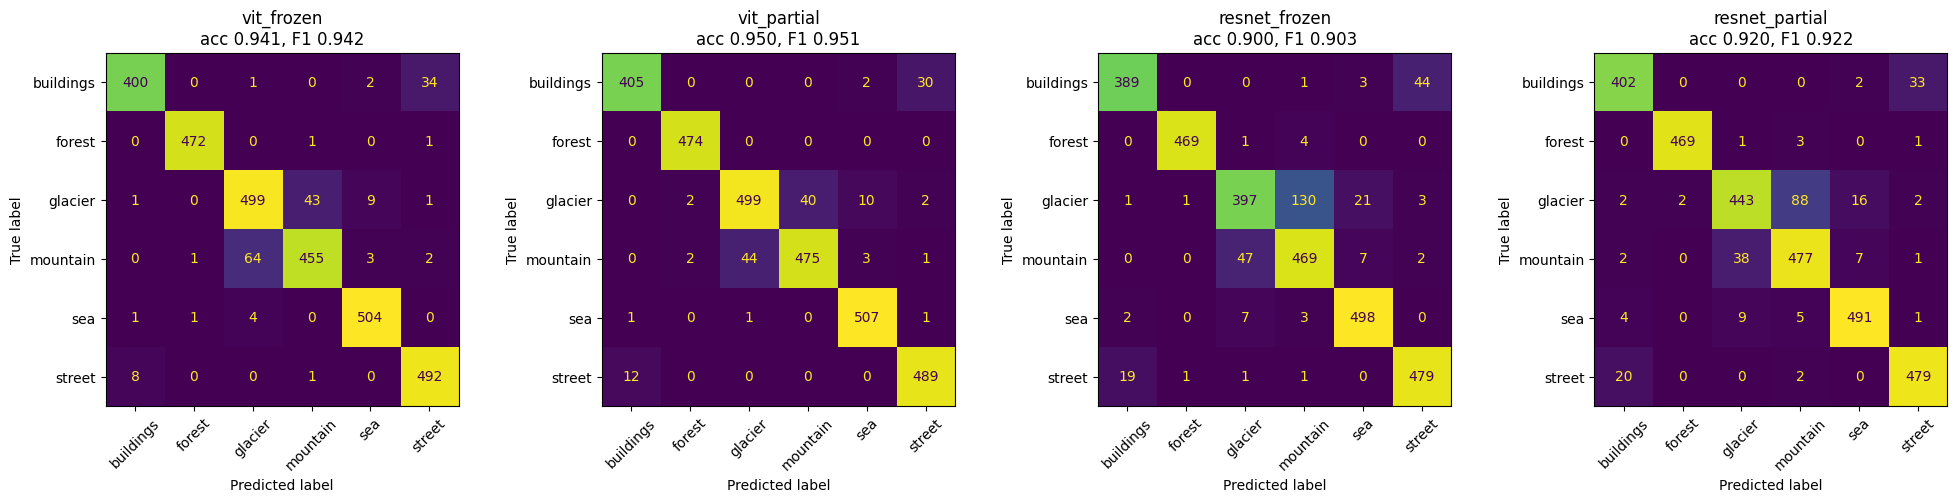

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))
for ax, n in zip(axes, NAMES):
    ConfusionMatrixDisplay(confusion_matrix(yt, PRED[n]), display_labels=labels).plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(f'{n}\nacc {quality.accuracy[n]:.3f}, F1 {quality.macro_f1[n]:.3f}')
plt.tight_layout(); plt.show()

## 5. Вычислительная стоимость

- **Параметры**: всего и обучаемых.
- **Размер checkpoint**: суммарный размер файлов `save_pretrained` (веса в fp32).
- **Latency (задержка)**: медиана времени одного прохода модели на случайном тензоре 224×224 после прогрева; для GPU с `cuda.synchronize`, иначе измерится только запуск ядер. Отдельно — полный путь «файл → предобработка → модель → ответ» для одного изображения.
- **Память**: пиковая `max_memory_allocated` на GPU при обучении (включает веса, градиенты и состояние оптимизатора) и при inference с batch 32.

In [41]:
def sync():
    if DEVICE == 'cuda':
        torch.cuda.synchronize()

@torch.inference_mode()
def latency_ms(pred, bs, device, n=30, warm=5):
    m, x = pred.model.to(device), torch.randn(bs, 3, 224, 224, device=device)
    for _ in range(warm): m(pixel_values=x)
    ts = []
    for _ in range(n):
        sync(); t = time.perf_counter(); m(pixel_values=x); sync(); ts.append(time.perf_counter() - t)
    pred.model.to(pred.device)
    return float(np.median(ts) * 1000)

def infer_peak_mb(pred, bs=32):
    if DEVICE != 'cuda':
        return float('nan')
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    base_mem = torch.cuda.memory_allocated()
    with torch.inference_mode():
        pred.model(pixel_values=torch.randn(bs, 3, 224, 224, device=DEVICE))
    sync()
    return (torch.cuda.max_memory_allocated() - base_mem) / 2 ** 20

def e2e_ms(pred, path, n=20):
    pred.predict(path)
    ts = []
    for _ in range(n):
        sync(); t = time.perf_counter(); pred.predict(path); ts.append(time.perf_counter() - t)
    return float(np.median(ts) * 1000)

sample_path = test_df.path[0]
cost = {}
for n in NAMES:
    d = MODELS / n
    cost[n] = {
        'params_M': sum(p.numel() for p in P[n].model.parameters()) / 1e6,
        'trainable_M': stats[n]['trainable_params'] / 1e6,
        'ckpt_MB': sum(f.stat().st_size for f in d.rglob('*') if f.is_file()) / 2 ** 20,
        'train_min': stats[n]['train_min'],
        'train_peak_MB': stats[n]['train_peak_mem_mb'],
        'infer_peak_MB_bs32': infer_peak_mb(P[n]),
        'lat_gpu_bs1_ms': latency_ms(P[n], 1, DEVICE),
        'lat_gpu_bs32_ms': latency_ms(P[n], 32, DEVICE),
        'lat_cpu_bs1_ms': latency_ms(P[n], 1, 'cpu', n=10, warm=2),
        'e2e_bs1_ms': e2e_ms(P[n], sample_path),
    }
cost = pd.DataFrame(cost).T
summary = quality[['accuracy', 'macro_f1']].join(cost)
summary.to_csv(WORK / 'summary.csv')
summary.round(3)

,accuracy,macro_f1,params_M,trainable_M,ckpt_MB,train_min,train_peak_MB,infer_peak_MB_bs32,lat_gpu_bs1_ms,lat_gpu_bs32_ms,lat_cpu_bs1_ms,e2e_bs1_ms
vit_frozen,0.941,0.942,21.668,0.002,82.680,2.895,788.491,129.188,7.273,122.844,121.010,10.094
vit_partial,0.950,0.951,21.668,7.101,82.680,3.007,1212.917,129.188,6.493,130.727,120.663,10.352
resnet_frozen,0.900,0.903,23.520,0.012,89.967,3.056,898.636,361.375,6.443,109.638,129.478,10.044
resnet_partial,0.920,0.922,23.520,14.977,89.967,3.009,1015.350,361.375,6.760,105.275,130.500,10.198


## 6. Где ViT и ResNet ошибаются по-разному

Сравниваем лучшие по схеме обучения модели с частичным fine-tuning: `vit_partial` и `resnet_partial`. Разбор строится на тех test-изображениях, где ответы моделей не совпали.

In [34]:
A, B = 'vit_partial', 'resnet_partial'
pa, pb = PRED[A], PRED[B]
ok_a, ok_b = pa == yt, pb == yt
groups = {'обе верны': ok_a & ok_b, 'только ViT верна': ok_a & ~ok_b, 'только ResNet верна': ~ok_a & ok_b,
          'обе ошиблись одинаково': ~ok_a & ~ok_b & (pa == pb), 'обе ошиблись по-разному': ~ok_a & ~ok_b & (pa != pb)}
print(pd.Series({k: int(v.sum()) for k, v in groups.items()}).to_frame('изображений'))

recall = pd.DataFrame({A: [ok_a[yt == c].mean() for c in range(len(labels))], B: [ok_b[yt == c].mean() for c in range(len(labels))]}, index=labels)
recall['ViT - ResNet'] = recall[A] - recall[B]
display(recall.round(3))

def top_pairs(pred, k=5):
    cm = confusion_matrix(yt, pred); np.fill_diagonal(cm, 0)
    idx = np.dstack(np.unravel_index(np.argsort(-cm.ravel())[:k], cm.shape))[0]
    return [f'{labels[i]} -> {labels[j]}: {cm[i, j]}' for i, j in idx]

print(A, top_pairs(pa)); print(B, top_pairs(pb))

pr = {n: LOGITS[n].softmax(-1).numpy() for n in (A, B)}
for n, ok in ((A, ok_a), (B, ok_b)):
    conf = pr[n].max(1)
    print(f'{n}: средняя уверенность на верных {conf[ok].mean():.3f}, на ошибках {conf[~ok].mean():.3f}')

                         изображений
обе верны                       2707
только ViT верна                 142
только ResNet верна               54
обе ошиблись одинаково            89
обе ошиблись по-разному            8


,vit_partial,resnet_partial,ViT - ResNet
buildings,0.927,0.920,0.007
forest,1.000,0.989,0.011
glacier,0.902,0.801,0.101
mountain,0.905,0.909,-0.004
sea,0.994,0.963,0.031
street,0.976,0.956,0.020


vit_partial ['mountain -> glacier: 44', 'glacier -> mountain: 40', 'buildings -> street: 30', 'street -> buildings: 12', 'glacier -> sea: 10']
resnet_partial ['glacier -> mountain: 88', 'mountain -> glacier: 38', 'buildings -> street: 33', 'street -> buildings: 20', 'glacier -> sea: 16']
vit_partial: средняя уверенность на верных 0.976, на ошибках 0.786
resnet_partial: средняя уверенность на верных 0.897, на ошибках 0.653


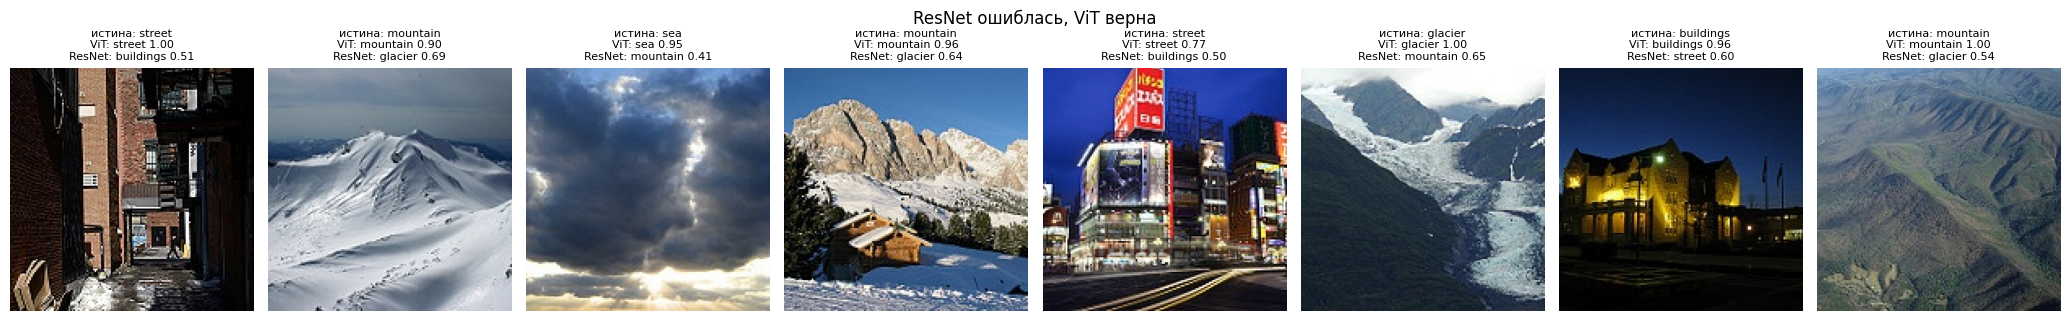

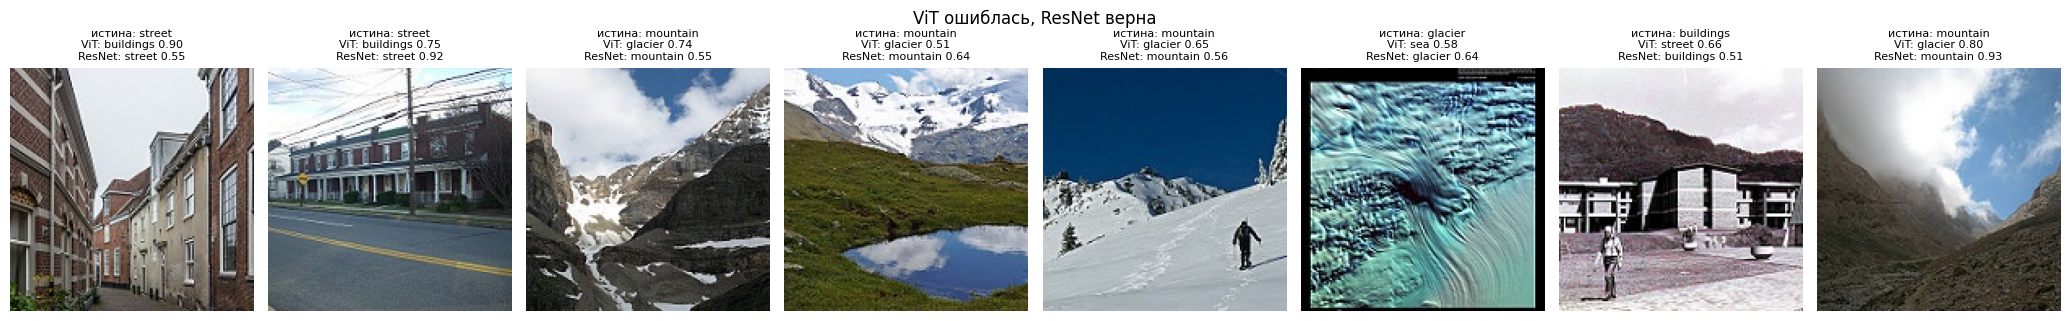

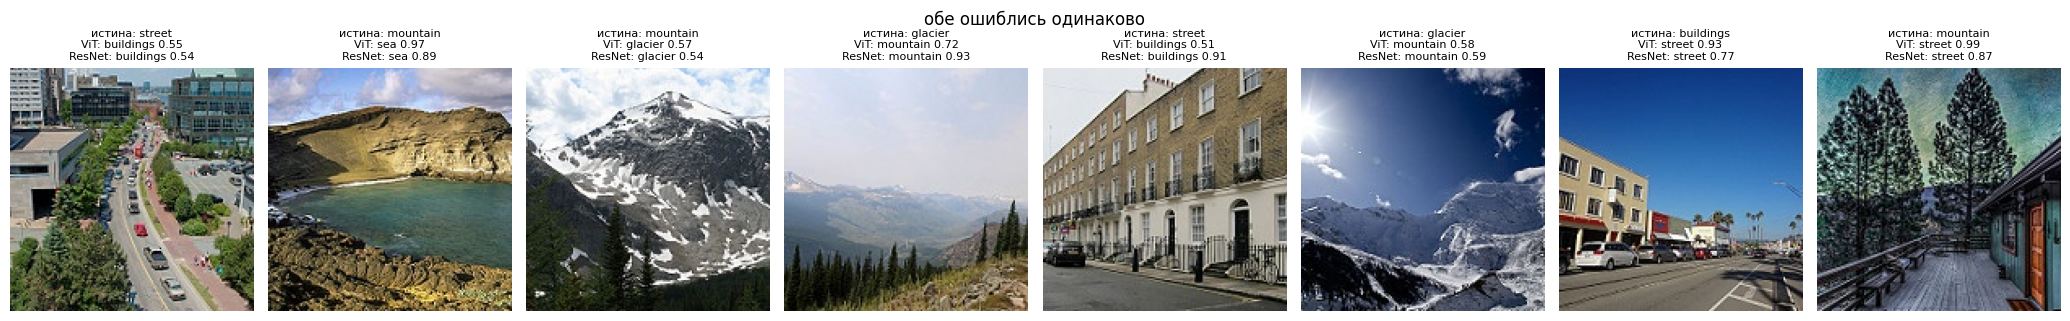

In [35]:
def show_cases(mask, title, n=8):
    idx = np.where(mask)[0]
    idx = np.random.default_rng(SEED).choice(idx, min(n, len(idx)), replace=False)
    fig, axes = plt.subplots(1, len(idx), figsize=(2.6 * len(idx), 3.4))
    for a, i in zip(np.atleast_1d(axes), idx):
        a.imshow(Image.open(test_df.path[i]).convert('RGB')); a.axis('off')
        a.set_title(f'истина: {labels[yt[i]]}\nViT: {labels[pa[i]]} {pr[A][i].max():.2f}\nResNet: {labels[pb[i]]} {pr[B][i].max():.2f}', fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_cases(groups['только ViT верна'], 'ResNet ошиблась, ViT верна')
show_cases(groups['только ResNet верна'], 'ViT ошиблась, ResNet верна')
show_cases(groups['обе ошиблись одинаково'], 'обе ошиблись одинаково')

### Наблюдения о различии ошибок

Ошибки ViT почти все общие, а ошибки ResNet — наполовину исправимы.

Обе модели ошиблись на 97 изображениях. Это 64% ошибок ViT и 41% ошибок ResNet.
На 89 из этих 97 обе модели выбрали один и тот же неверный класс. Такие случаи похожи на неоднозначные сцены или неточные метки, а не на слабость конкретной архитектуры. Ни одна из моделей их не решает.
Из 239 ошибок ResNet ViT правильно решает 142 (59%). Из 151 ошибки ViT ResNet решает только 54 (36%). Разница в качестве держится главным образом на изображениях, которые ResNet ошибочно относит не туда, а ViT определяет верно.
Разрыв по классам почти целиком создаёт одна пара: glacier → mountain.

Полнота — доля изображений класса, найденных моделью. Лидирует glacier: 0.902 у ViT против 0.801 у ResNet, разрыв 10.1 п.п. Остальные классы различаются меньше чем на 3.5 п.п., а на mountain модели равны (0.905 против 0.909).
Ошибок «glacier → mountain» у ResNet 88, у ViT 40. Эта разница в 48 ошибок объясняет большую часть разрыва по glacier: на классе в 553 изображения полнота ResNet 0.801 даёт 110 ошибок, из них 88 — в mountain.
В обратную сторону («mountain → glacier») модели почти одинаковы: 38 и 44. У ViT путаница между этими двумя классами симметрична (44 и 40), у ResNet смещена в одну сторону: ledниковые сцены она часто принимает за горы.
Почему так, я не проверял. Возможное объяснение: ResNet опирается на локальную текстуру (камень, снег), а у обеих сцен она похожа. Чтобы проверить, нужно смотреть на сами изображения из этой пары (раздел «только ViT верна»).
Общая структура путаницы одинакова у обеих моделей. Самые частые пары совпадают: buildings → street (30 и 33), street → buildings (12 и 20), glacier → sea (10 и 16). Направление «здание принимается за улицу» преобладает в обеих моделях: вероятно, на таких снимках улица есть в кадре вместе со зданием, и метка условна.

Уверенность: ViT чуть самоуверенный, ResNet скорее недоуверенный.

Средняя уверенность на верных / на ошибках: ViT 0.976 / 0.786, ResNet 0.897 / 0.653.
Сравнивая среднюю уверенность по всем предсказаниям с accuracy, получаем: у ViT ≈ 0.966 при accuracy 0.950 (завышает на 1.7 п.п.), у ResNet ≈ 0.878 при accuracy 0.920 (занижает на 4.3 п.п.). Это грубая оценка калибровки, настоящая метрика (ECE) не считалась.
На ошибках ViT остаётся довольно уверенным (0.79, то есть 81% от его уверенности на верных ответах), ResNet — менее (73%). Поэтому порог по уверенности для отсева сомнительных ответов у ResNet разделяет верные и неверные ответы немного лучше.

## 7. Чувствительность к crop, закрытию части изображения и фону

Возмущения применяются к случайным 1000 изображениям test (seed 42) до image processor:
- `crop_center_60`: вырезается центральный квадрат 60% стороны, processor растягивает его до входа модели (модель видит увеличенный фрагмент);
- `occlude_25`: серый квадрат (25% площади) в случайном месте;
- `bg_swap`: центральный квадрат 50% стороны вставляется в изображение из другого класса: объект остаётся, фон вокруг становится чужим. Правильным ответом остаётся исходный класс центра, поэтому падение точности показывает, насколько модель опирается на окружение, а не на центральный объект. Для сцен («лес», «море») окружение и есть признак класса, так что часть падения неизбежна.

In [36]:
sub = test_df.sample(1000, random_state=SEED).reset_index(drop=True)
rng = np.random.default_rng(SEED)
orig = [Image.open(p).convert('RGB') for p in sub.path]

def crop_center(img, frac=0.6):
    w, h = img.size; cw, ch = int(w * frac), int(h * frac); l, t = (w - cw) // 2, (h - ch) // 2
    return img.crop((l, t, l + cw, t + ch))

def occlude(img, area=0.25):
    w, h = img.size; s = int(np.sqrt(area * w * h)); l, t = rng.integers(0, w - s + 1), rng.integers(0, h - s + 1)
    out = img.copy(); out.paste((127, 127, 127), (l, t, l + s, t + s)); return out

def bg_swap(img, i, frac=0.5):
    cands = np.where(sub.y.values != sub.y[i])[0]
    bg = orig[rng.choice(cands)].resize(img.size)
    patch = crop_center(img, frac); w, h = img.size
    bg.paste(patch, ((w - patch.width) // 2, (h - patch.height) // 2)); return bg

variants = {
    'clean': orig,
    'crop_center_60': [crop_center(im) for im in orig],
    'occlude_25': [occlude(im) for im in orig],
    'bg_swap': [bg_swap(im, i) for i, im in enumerate(orig)],
}

ys = sub.y.values
rob = pd.DataFrame({n: {v: accuracy_score(ys, P[n].logits(imgs).argmax(1).numpy()) for v, imgs in variants.items()} for n in NAMES}).T
display(rob.round(3))
display((rob.sub(rob['clean'], axis=0)).drop(columns='clean').round(3))

,clean,crop_center_60,occlude_25,bg_swap
vit_frozen,0.950,0.931,0.938,0.118
vit_partial,0.953,0.940,0.949,0.117
resnet_frozen,0.896,0.892,0.885,0.171
resnet_partial,0.926,0.875,0.859,0.327


,crop_center_60,occlude_25,bg_swap
vit_frozen,-0.019,-0.012,-0.832
vit_partial,-0.013,-0.004,-0.836
resnet_frozen,-0.004,-0.011,-0.725
resnet_partial,-0.051,-0.067,-0.599


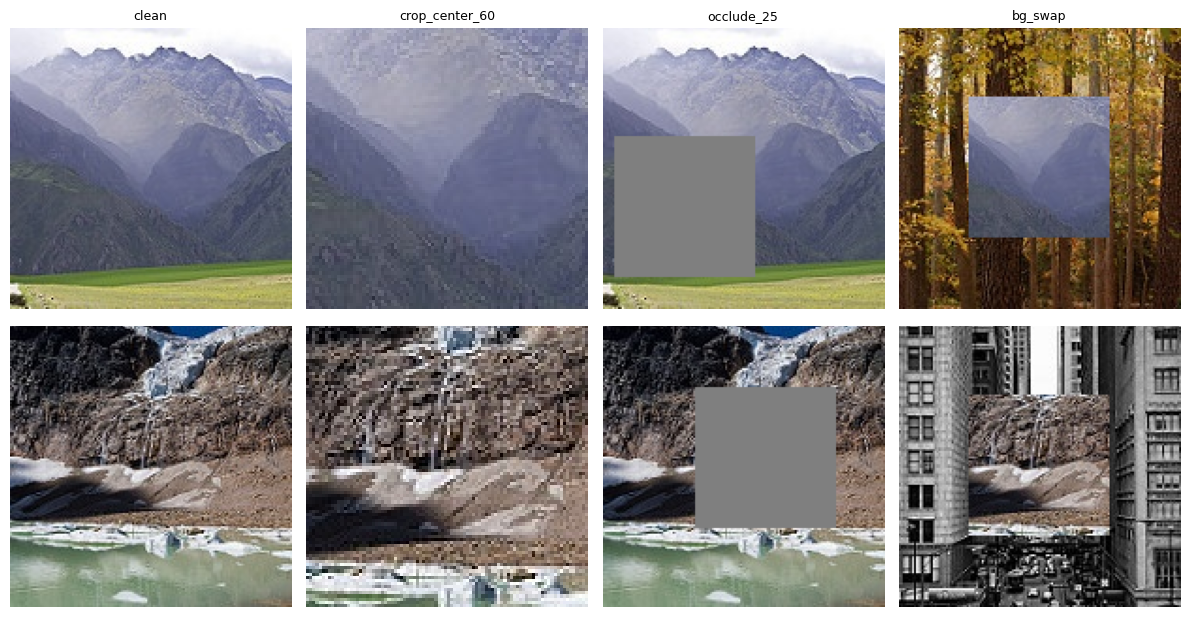

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6.4))
for r, i in enumerate((0, 1)):
    for a, (v, imgs) in zip(axes[r], variants.items()):
        a.imshow(imgs[i]); a.set_title(v if r == 0 else '', fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

## 8. Функция inference в работе

In [38]:
P['vit_partial'].predict(test_df.path[0])

[('buildings', 0.9994), ('sea', 0.0003), ('glacier', 0.0001)]

In [39]:
idx = [0, 500, 1500]
for n in ('vit_partial', 'resnet_partial'):
    print(n)
    for i, r in zip(idx, P[n].predict([test_df.path[i] for i in idx])):
        print('  истина:', test_df.label[i], '| ответ:', r)

arr = np.array(Image.open(test_df.path[0]).convert('RGB'))
print('numpy-вход:', P['vit_partial'].predict(arr, topk=1))

for n in NAMES:
    ref = LOGITS[n][:8]
    assert torch.allclose(P[n].logits(test_df.path[:8].tolist()), ref, atol=1e-4)
print('inference воспроизводит логиты, по которым считались метрики')

vit_partial
  истина: buildings | ответ: [('buildings', 0.9994), ('sea', 0.0003), ('glacier', 0.0001)]
  истина: forest | ответ: [('forest', 0.999), ('glacier', 0.0009), ('buildings', 0.0)]
  истина: mountain | ответ: [('mountain', 0.9833), ('glacier', 0.0151), ('forest', 0.0014)]
resnet_partial
  истина: buildings | ответ: [('buildings', 0.9937), ('street', 0.004), ('sea', 0.0012)]
  истина: forest | ответ: [('forest', 0.8963), ('glacier', 0.0349), ('mountain', 0.0294)]
  истина: mountain | ответ: [('mountain', 0.9041), ('glacier', 0.0455), ('forest', 0.0214)]
numpy-вход: [('buildings', 0.9994)]
inference воспроизводит логиты, по которым считались метрики
